In [ ]:
import glob
import torch
import soxr
import numpy as np
import torch.nn.functional as F

from nnAudio.features import CQT, STFT
from src.utils import load_audio, speed_up, get_spectrum, get_fakeprints, get_freqs, get_freqs_mask


DEVICE = torch.device("cpu")

N_FFT = 1 << 14
SR = 44100
BINS_PER_OCTAVE = 96
BINS_PER_OCTAVE_STFT = 96 * 20
AREA = 20
FREQ_RANGE = [5000, 16000]
FMIN = 32.7
SHOW_AI = True
TRANSFORM = "stft"

ai_dir = "/path/to/sunov5/"
human_dir = "/path/to/fma_small/"
data_dir = ai_dir if SHOW_AI else human_dir

hop_length = N_FFT // 2
fmax = SR / 2  # Maximum frequency that can be represented

log = (TRANSFORM == "cqt")
freqs = get_freqs(n_fft=N_FFT, sr=SR, log=log, bins_per_octave=BINS_PER_OCTAVE, fmin=FMIN)
mask = get_freqs_mask(freqs, sr=SR, freq_range=FREQ_RANGE)
freqs = freqs.to(DEVICE)
freqs_crop = freqs[mask]

cqt_transform = CQT(
    sr=SR,
    hop_length=hop_length,
    fmin=FMIN,
    fmax=fmax,
    bins_per_octave=BINS_PER_OCTAVE,
    output_format="Magnitude",
    verbose=False,
).to(DEVICE)

stft_transform = STFT(
    sr=SR,
    n_fft=N_FFT,
    hop_length=hop_length,
    output_format="Magnitude",
    verbose=False,
).to(DEVICE)

file_paths = glob.glob(f"{data_dir}/**/*.mp3", recursive=True)
audio_paths = np.random.choice(file_paths, size=2, replace=False)

waveforms = []
for path in audio_paths:
    waveform, sr = load_audio(path)
    if sr != SR:
        print(f"Resampling {path} from {sr} Hz to {SR} Hz")
        waveform = soxr.resample(waveform.T, sr, SR, quality="VHQ").T
        waveform = torch.from_numpy(waveform)
    waveform = waveform.mean(dim=0, keepdim=True)
    waveforms.append(waveform)

waveform1 = waveforms[0]
waveform2 = waveforms[1]
print(f"Loaded {audio_paths[0]} with shape {waveform1.shape} and sample rate {SR}")
print(f"Loaded {audio_paths[1]} with shape {waveform2.shape} and sample rate {SR}")

/Users/emiledugelay/Machine-Learning/deezer/robust-deepfake-detector/.venv/lib/python3.13/site-packages/nnAudio/utils.py:429: SyntaxWarning: If fmax is given, n_bins will be ignored
  warnings.warn("If fmax is given, n_bins will be ignored", SyntaxWarning)


Resampling /Users/emiledugelay/datasets/sunov5/d5133230dabb34e32ee29fd65feb83736d19c1418596ebf951574ff03bc6f508.mp3 from 48000 Hz to 44100 Hz
Resampling /Users/emiledugelay/datasets/sunov5/05ccdb596fe345779d743562d7800dd8681a46d16b50adbacd502365bab68478.mp3 from 48000 Hz to 44100 Hz
Loaded /Users/emiledugelay/datasets/sunov5/d5133230dabb34e32ee29fd65feb83736d19c1418596ebf951574ff03bc6f508.mp3 with shape torch.Size([1, 8839403]) and sample rate 44100
Loaded /Users/emiledugelay/datasets/sunov5/05ccdb596fe345779d743562d7800dd8681a46d16b50adbacd502365bab68478.mp3 with shape torch.Size([1, 5567183]) and sample rate 44100


In [9]:
import math

def stft_to_log(fp, freqs, sr, bins_per_octave, freq_range):
    mask = get_freqs_mask(freqs, sr=sr, freq_range=freq_range)
    freqs_crop = freqs[mask]
    fp_crop = fp[:, mask]

    n_log_bins = int(math.ceil(bins_per_octave * math.log2(freq_range[1] / freq_range[0])))
    log_freqs = torch.logspace(
        math.log10(freq_range[0]),
        math.log10(freq_range[1]),
        steps=n_log_bins,
    )  # (n_log_bins,)

    freq_indices = (log_freqs - freqs_crop[0]) / (freqs_crop[1] - freqs_crop[0])
    freq_indices = freq_indices.clamp(0, len(freqs_crop) - 1)
    idx_low = freq_indices.long()
    idx_high = (idx_low + 1).clamp(max=len(freqs_crop) - 1)
    alpha = (freq_indices - idx_low.float())
    fp_log = (1 - alpha) * fp_crop[:, idx_low] + alpha * fp_crop[:, idx_high]
    return fp_log

In [31]:
SPEED_FACTOR = 0.86553656

su_waveform1 = speed_up(waveform1, sr=SR, speed_factor=SPEED_FACTOR)

if TRANSFORM == "cqt":
    transform_fn = cqt_transform
elif TRANSFORM == "stft":
    transform_fn = stft_transform
else:
    raise ValueError(f"Unknown transform: {TRANSFORM}")

spec1 = get_spectrum(transform_fn, waveform1)
su_spec1 = get_spectrum(transform_fn, su_waveform1)
spec2 = get_spectrum(transform_fn, waveform2)

spec1 = spec1.mean(dim=-1)
su_spec1 = su_spec1.mean(dim=-1)
spec2 = spec2.mean(dim=-1)

fp1 = get_fakeprints(spec1, area=AREA)
su_fp1 = get_fakeprints(su_spec1, area=AREA)
fp2 = get_fakeprints(spec2, area=AREA)

fp1= torch.clip(fp1, None, 8.0)
su_fp1 = torch.clip(su_fp1, None, 8.0)
fp2 = torch.clip(fp2, None, 8.0)

fp1_crop = fp1[:, mask]
su_fp1_crop = su_fp1[:, mask]
fp2_crop = fp2[:, mask]

fp1_crop = torch.clip(fp1_crop, None, 8.0)
su_fp1_crop = torch.clip(su_fp1_crop, None, 8.0)
fp2_crop = torch.clip(fp2_crop, None, 8.0)

fp1_crop.shape, su_fp1_crop.shape, fp2_crop.shape

(torch.Size([1, 4087]), torch.Size([1, 4087]), torch.Size([1, 4087]))

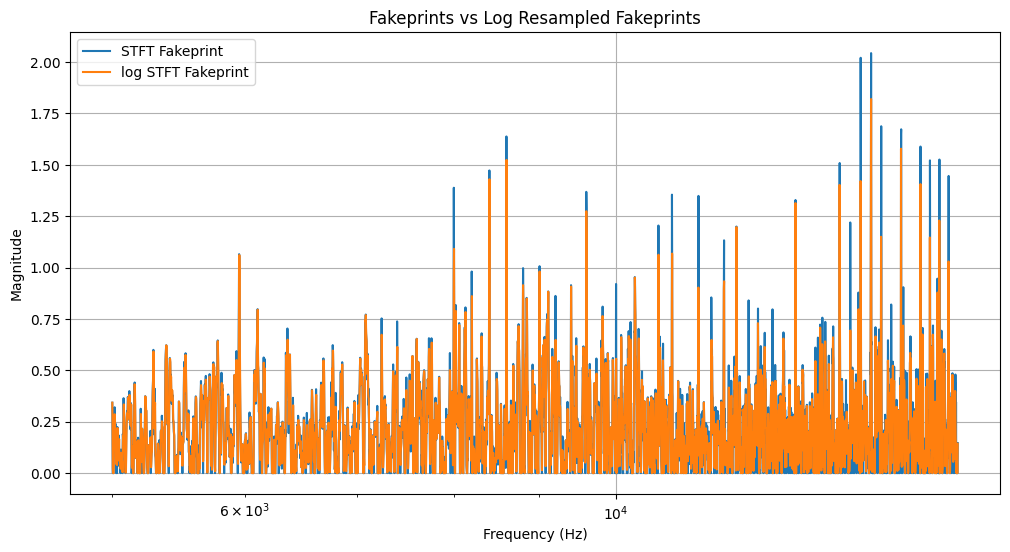

In [32]:
import matplotlib.pyplot as plt

fp_log_crop = stft_to_log(fp1, freqs, sr=SR, bins_per_octave=BINS_PER_OCTAVE_STFT, freq_range=FREQ_RANGE)
log_freqs = get_freqs(n_fft=N_FFT, sr=SR, log=True, bins_per_octave=BINS_PER_OCTAVE_STFT, fmin=FMIN)
log_mask = get_freqs_mask(log_freqs, sr=SR, freq_range=FREQ_RANGE)
log_freqs_crop = log_freqs[log_mask]

plt.figure(figsize=(12, 6))
plt.plot(freqs_crop, fp1_crop[0].cpu(), label="STFT Fakeprint")
plt.plot(log_freqs_crop, fp_log_crop[0].cpu(), label="log STFT Fakeprint")
plt.xscale("log")
plt.xlabel("Frequency (Hz)")
plt.ylabel("Magnitude")
plt.title("Fakeprints vs Log Resampled Fakeprints")
plt.legend()
plt.grid()
plt.show()



In [33]:
import torch

def shift_spectre(spectre, decalage, dim=1):
    """
    Décale un tenseur de spectre le long d'une dimension donnée.
    
    Args:
        spectre (torch.Tensor): Le tenseur à décaler, ex: de forme (B, F).
        decalage (int): Le nombre de bins de décalage. Positif vers la droite, négatif vers la gauche.
        dim (int): La dimension des fréquences (1 par défaut pour (B, F)).
    """
    # Si le décalage est de 0, on ne fait rien pour économiser du calcul
    if decalage == 0:
        return spectre
        
    # 1. Décalage circulaire avec torch.roll
    spectre_decale = torch.roll(spectre, shifts=decalage, dims=dim)
    
    # 2. Remplacement des valeurs qui ont fait le tour (Wrap-around) par 0
    if decalage > 0:
        # Les hautes fréquences sont revenues à gauche (au début) : on les met à zéro
        spectre_decale[:, :decalage] = 0.0
    elif decalage < 0:
        # Les basses fréquences sont passées à droite (à la fin) : on les met à zéro
        spectre_decale[:, decalage:] = 0.0
        
    return spectre_decale

def apply_speed_mask(fp, speed_factor, freqs_log, freq_range):
    """
    When speed < 1.0, content above (fmax * speed_factor) is invalid.
    When speed > 1.0, content below (fmin * speed_factor) is invalid.
    
    fp:          (B, n_log_bins)
    speed_factor: float
    freqs_log:   (n_log_bins,) Hz values of log-resampled bins
    freq_range:  (2,) The frequency range (min, max) in Hz
    """
    if speed_factor < 1.0:
        valid_fmax = freq_range[1] * speed_factor
        mask = freqs_log <= valid_fmax  # (n_log_bins,)
    else:
        valid_fmin = freq_range[0] * speed_factor
        mask = freqs_log >= valid_fmin

    fp = fp * mask.float()  # zero out invalid bins
    return fp

Frequency scaling factors for bin shifts: [0.86553656 0.86584909 0.86616173 0.86647448 0.86678735 0.86710033
 0.86741342 0.86772662 0.86803994 0.86835337 0.86866692 0.86898058
 0.86929435 0.86960823 0.86992223 0.87023634 0.87055056 0.8708649
 0.87117935 0.87149392 0.8718086  0.87212339 0.87243829 0.87275331
 0.87306845 0.87338369 0.87369905 0.87401453 0.87433012 0.87464582
 0.87496164 0.87527757 0.87559361 0.87590977 0.87622604 0.87654243
 0.87685893 0.87717555 0.87749228 0.87780912 0.87812608 0.87844315
 0.87876034 0.87907764 0.87939506 0.87971259 0.88003024 0.880348
 0.88066587 0.88098386 0.88130197 0.88162019 0.88193852 0.88225697
 0.88257554 0.88289422 0.88321301 0.88353192 0.88385095 0.88417009
 0.88448934 0.88480871 0.8851282  0.8854478  0.88576752 0.88608735
 0.8864073  0.88672736 0.88704754 0.88736784 0.88768825 0.88800877
 0.88832941 0.88865017 0.88897104 0.88929203 0.88961314 0.88993436
 0.8902557  0.89057715 0.89089872 0.8912204  0.8915422  0.89186412
 0.89218616 0.89250831 

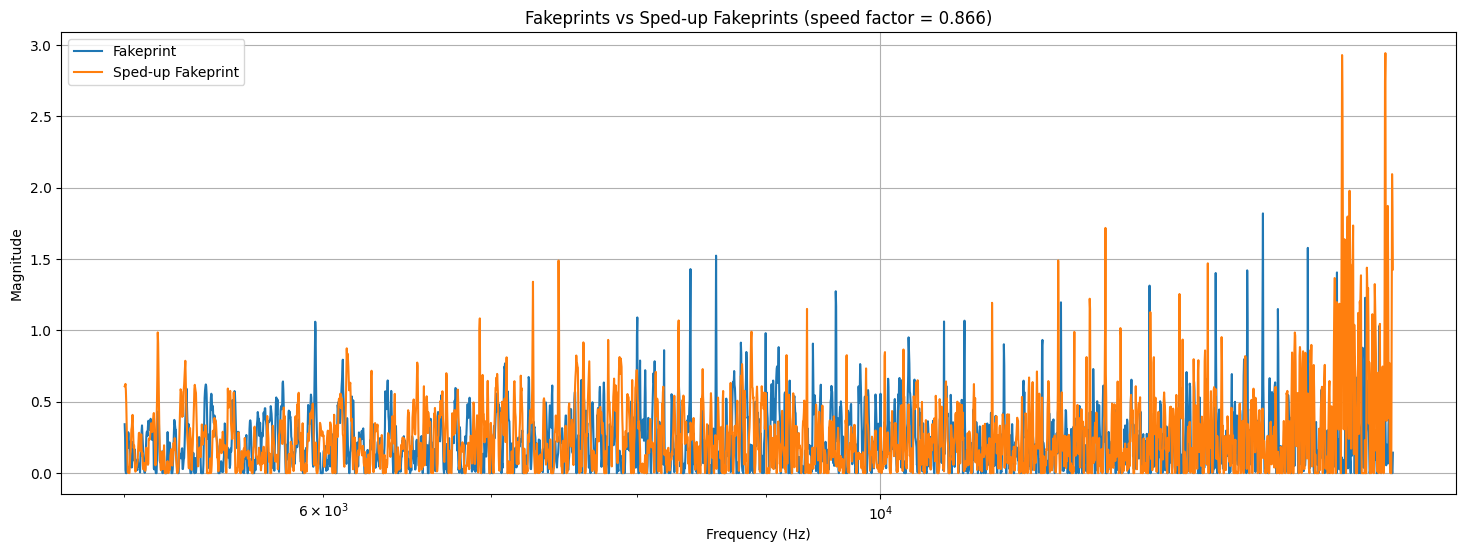

In [34]:
import matplotlib.pyplot as plt

bin_shifts = np.arange(-400, 400)  # Example bin shifts for 100 bins up and down
a = 2 ** (bin_shifts / BINS_PER_OCTAVE_STFT)  # Calculate the frequency scaling factor
print(f"Frequency scaling factors for bin shifts: {a}")

applied_bin_shift = BINS_PER_OCTAVE_STFT * np.log2(SPEED_FACTOR)  # Calculate the bin shift corresponding to the speed factor
print(f"Applied bin shift for speed factor {SPEED_FACTOR}: {applied_bin_shift:.2f} bins")


su_fp_log_crop = stft_to_log(su_fp1, freqs, sr=SR, bins_per_octave=BINS_PER_OCTAVE_STFT, freq_range=FREQ_RANGE)

# plot fakeprints & sped up fakeprints
plt.figure(figsize=(18, 6))
plt.plot(log_freqs_crop, fp_log_crop[0].cpu(), label="Fakeprint")
plt.plot(log_freqs_crop, su_fp_log_crop[0].cpu(), label="Sped-up Fakeprint")
#plt.plot(freqs_crop, su_fp1[0].cpu(), label="Shifted Fakeprint", linestyle="dashed")
#plt.plot(log_freqs, shifted_fp_log[0].cpu(), label="Shifted Fakeprint", linestyle="dashed")
plt.xscale("log")
plt.xlabel("Frequency (Hz)")
plt.ylabel("Magnitude")
plt.title("Fakeprints vs Sped-up Fakeprints (speed factor = {:.3f})".format(SPEED_FACTOR))
plt.legend()
plt.grid()
plt.show()

argmax crosscorr: 1210
predicted lag index: 1211


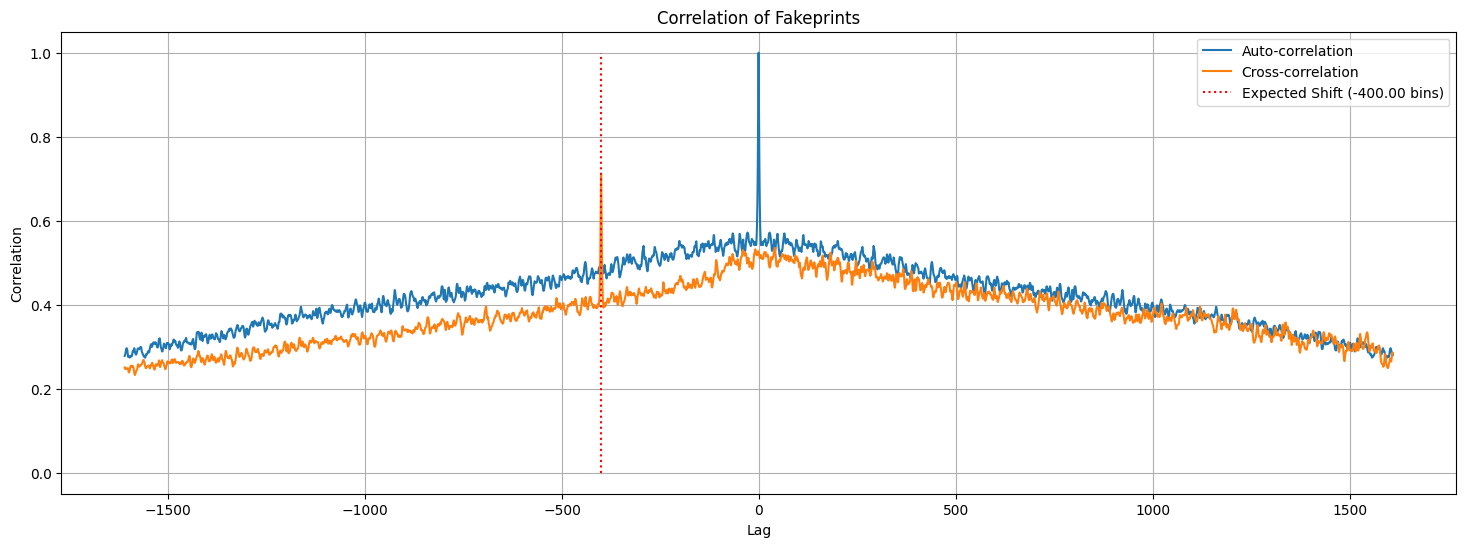

In [35]:
fp_log_norm = F.normalize(fp_log_crop, dim=-1)
su_fp_log_norm = F.normalize(su_fp_log_crop, dim=-1)

cross_corr = F.conv1d(fp_log_norm.unsqueeze(1), fp_log_norm.unsqueeze(1), padding="same").squeeze()
cross_corr_su = F.conv1d(su_fp_log_norm.unsqueeze(1), fp_log_norm.unsqueeze(1), padding="same").squeeze()

lags = np.arange(-len(fp_log_crop[0])//2 , len(fp_log_crop[0])//2)

shifted_cross_corr = shift_spectre(cross_corr.unsqueeze(0), int(round(applied_bin_shift)), dim=1).squeeze(0)

lag_index = len(fp_log_crop[0]) // 2 + int(round(applied_bin_shift))

print(f"argmax crosscorr: {torch.argmax(cross_corr_su).item()}")
print(f"predicted lag index: {lag_index}")

plt.figure(figsize=(18, 6))
plt.plot(lags, cross_corr, label="Auto-correlation")
plt.plot(lags, cross_corr_su, label="Cross-correlation")
#plt.plot(lags, shifted_cross_corr, label="Shifted Auto-correlation", linestyle="dashed")
plt.vlines(int(round(applied_bin_shift)), ymin=0, ymax=1, color="red", linestyle="dotted", label=f"Expected Shift ({applied_bin_shift:.2f} bins)")
plt.xlabel("Lag")
plt.ylabel("Correlation")
plt.title("Correlation of Fakeprints")
plt.legend()
plt.grid()
plt.show()